# Deep learning in finance

## Deep Hedging — The 2-Asset Case (Project 2)

Student name(s): *[Your name here]*

This notebook implements deep hedging for a **two-asset** option, following the project description.

We extend the single-asset deep hedging approach from Session 5 to two correlated assets. The structure and code conventions are the same as in `Deep_hedging.ipynb`.

## Problem description

We consider two assets with values $S^1_t$ and $S^2_t$ following a two-dimensional log-normal model:

$$
\begin{cases}
\log S^1_{t_{j+1}} = \log S^1_{t_j} + \mu_1 \Delta t + \sigma_1 \sqrt{\Delta t}\, G^1_j \\
\log S^2_{t_{j+1}} = \log S^2_{t_j} + \mu_2 \Delta t + \sigma_2 \sqrt{\Delta t}\, G^2_j
\end{cases}
$$

where $(G^1_j, G^2_j) \sim \mathcal{N}_{\mathbb{R}^2}(0, C)$ with correlation matrix $C = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}$.

**Option payoff:** ATM call on the product of the two assets (normalised by their initial values):
$$
g(S^1_T, S^2_T) = \left( \frac{S^1_T S^2_T}{S^1_0 S^2_0} - 1 \right)^+
$$

**Hedging portfolio** with two delta components $(\delta^1_{t_j}, \delta^2_{t_j})$, self-financing dynamics:
$$
V_{t_{j+1}} = V_{t_j} + r\left(V_{t_j} - \sum_{k=1}^{2} \delta^k_{t_j} S^k_{t_j}\right)\Delta t + \sum_{k=1}^{2} \delta^k_{t_j}\left(S^k_{t_{j+1}} - S^k_{t_j}\right)
$$

**Deep hedging strategy:** the two delta components are parameterised by neural networks at each time step:
$$
\bigl(\delta^1_{t_j}, \delta^2_{t_j}\bigr) = h_{\theta_j}\bigl(S^1_{t_j}, S^2_{t_j}\bigr)
$$

and the initial option premium $\pi_0$ is also learned.

In [1]:
import numpy as np
import tensorflow as tf

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras

from keras.layers import Subtract, Multiply, Lambda, Add, Concatenate
from keras import initializers

import matplotlib.pyplot as plt

I0000 00:00:1775145689.964788   17019 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Parameters

In [2]:
# Time grid
N = 100          # number of time steps
T = 1            # maturity (years)

# Initial asset prices
S1_0 = 1.0
S2_0 = 1.0

# Model parameters
mu1    = 0.025   # drift of asset 1
mu2    = -0.01   # drift of asset 2
sigma1 = 0.22    # volatility of asset 1
sigma2 = 0.30    # volatility of asset 2
rho    = 0.5     # correlation between the two Brownian motions
r      = 0.04    # risk-free interest rate

# Correlation matrix and its Cholesky factor
C = np.array([[1.0, rho],
              [rho, 1.0]])
L = np.linalg.cholesky(C)   # lower-triangular, L @ L.T = C

print("Correlation matrix C:")
print(C)
print("Cholesky factor L:")
print(L)

Correlation matrix C:
[[1.  0.5]
 [0.5 1. ]]
Cholesky factor L:
[[1.        0.       ]
 [0.5       0.8660254]]


$\blacktriangleright$ **Remark on the option price.** There is no closed-form Black-Scholes formula for the product call $\left(S^1_T S^2_T / (S^1_0 S^2_0) - 1\right)^+$ with two correlated assets. The option price learned by the deep model is therefore used as the reference, and we assess its plausibility by comparing it against a **Monte Carlo estimate** computed below.

In [3]:
import scipy.stats as sps

# Monte Carlo estimate of the option price using risk-neutral dynamics
# Under risk-neutral measure: mu_k is replaced by r (risk-neutral drift).
# We use N_mc paths with the exact same GBM but drift = r.
N_mc = 10**6
np.random.seed(0)
grid = [(i / N) * T for i in range(N + 1)]
Delta_T = grid[1] - grid[0]

mu_rn = np.array([r, r])        # risk-neutral drifts
sigma_vec = np.array([sigma1, sigma2])

log_S = np.zeros((N_mc, 2))
for j in range(N):
    Z = np.random.normal(0, 1, (N_mc, 2))
    log_S += mu_rn * Delta_T + sigma_vec * np.sqrt(Delta_T) * (Z @ L.T)

S_T = np.exp(log_S)   # S^k_T / S^k_0 (since log(S^k_T/S^k_0) = sum of increments)
product_payoff_mc = np.maximum(S_T[:, 0] * S_T[:, 1] - 1.0, 0.0)
price_MC = np.exp(-r * T) * np.mean(product_payoff_mc)
price_MC_std = np.exp(-r * T) * np.std(product_payoff_mc) / np.sqrt(N_mc)

print("Monte Carlo option price estimate: %1.4f  (std err: %1.5f)" % (price_MC, price_MC_std))

Monte Carlo option price estimate: 0.3001  (std err: 0.00046)


## Neural network architecture

We use the same architecture as in Session 5: **one network per time step** $t_j$, mapping $(S^1_{t_j}, S^2_{t_j}) \in \mathbb{R}^2$ to the hedge vector $(\delta^1_{t_j}, \delta^2_{t_j}) \in \mathbb{R}^2$.

In [4]:
# Architecture parameters
m = 2    # number of assets (input/output dimension for the hedging networks)
d = 3    # number of layers per network (including output layer)
n = 64   # number of nodes in hidden layers (wider than 1D to compensate for higher input dimension)

# Build all layers: N time steps × d layers each
layers = []

for j in range(N):
    for k in range(d):
        if k < d - 1:
            layer = keras.layers.Dense(
                units=n,
                activation="tanh",
                trainable=True,
                kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
                bias_initializer="random_normal",
                name="h" + str(k) + "_t" + str(j),
            )
        else:
            # Output layer: m=2 units (one per asset delta), linear activation
            layer = keras.layers.Dense(
                units=m,
                activation="linear",
                trainable=True,
                kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
                bias_initializer="random_normal",
                name="h" + str(k) + "_t" + str(j),
            )
        layers = layers + [layer]

## Training set — correlated 2D GBM trajectories

In [5]:
N_train = 10**5

mu_vec = np.array([mu1, mu2])

# Simulate correlated log-increments using Cholesky decomposition:
#   G_j = L @ Z_j,  Z_j ~ N(0, I_2)  =>  G_j ~ N(0, C)
log_increments = [
    mu_vec * Delta_T + sigma_vec * np.sqrt(Delta_T) * (np.random.normal(0, 1, (N_train, 2)) @ L.T)
    for _ in range(N)
]  # each element: shape (N_train, 2)

# For the hedge_eval input we use a 1D grid varying S1 (with S2 fixed at S2_0)
# This allows us to visualise delta profiles as functions of S1 after training
S1_eval_grid = S1_0 * np.linspace(0.5, 1.5, N_train)
hedge_eval_train = np.column_stack([
    S1_eval_grid,
    S2_0 * np.ones(N_train)
])  # shape (N_train, 2)

xtrain = (
    [np.column_stack([S1_0 * np.ones(N_train), S2_0 * np.ones(N_train)])]  # initial price vector
    + [np.zeros((N_train, 1))]                # initial accumulated gain (scalar hedge, shape (N_train,1))
    + [hedge_eval_train]                      # delta visualisation grid
    + [np.zeros((N_train, m))]                # premium input (zeros → output = learnable bias)
    + log_increments                          # N correlated log-increment arrays
)

ytrain = np.zeros((N_train, 1))

print("Training set built: %d trajectories." % N_train)

Training set built: 100000 trajectories.


Let us plot a sample of trajectories from the training set:

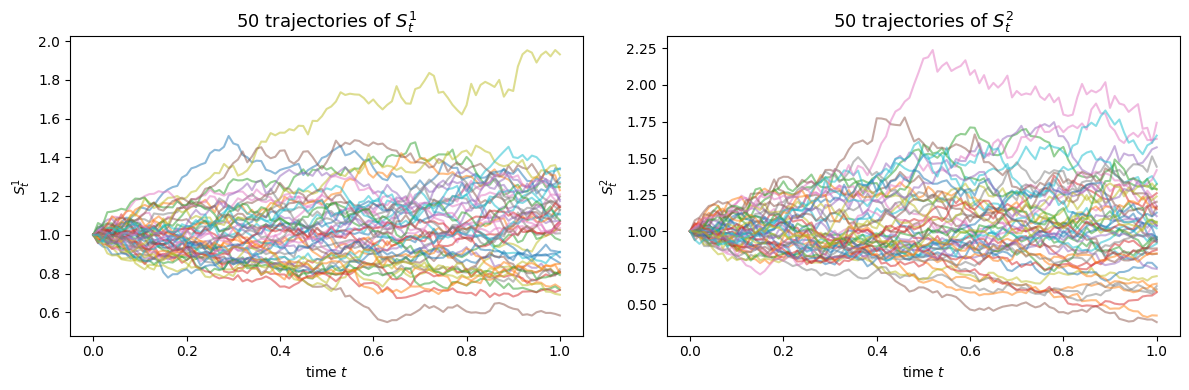

In [6]:
M = 50  # number of trajectories to plot

# Reconstruct price paths from log-increments
log_incr_array = np.array(log_increments)  # shape (N, N_train, 2)

log_S1 = np.cumsum(log_incr_array[:, :M, 0], axis=0)  # shape (N, M)
log_S2 = np.cumsum(log_incr_array[:, :M, 1], axis=0)

traj_S1 = np.vstack([S1_0 * np.ones((1, M)), S1_0 * np.exp(log_S1)])  # shape (N+1, M)
traj_S2 = np.vstack([S2_0 * np.ones((1, M)), S2_0 * np.exp(log_S2)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(grid, traj_S1, alpha=0.5)
axes[0].set_title("%d trajectories of $S^1_t$" % M, fontsize=13)
axes[0].set_xlabel("time $t$")
axes[0].set_ylabel("$S^1_t$")

axes[1].plot(grid, traj_S2, alpha=0.5)
axes[1].set_title("%d trajectories of $S^2_t$" % M, fontsize=13)
axes[1].set_xlabel("time $t$")
axes[1].set_ylabel("$S^2_t$")

plt.tight_layout()
plt.show()

## Deep hedging model construction

Key differences with respect to the 1D model:

1. The `hedge` input has shape `(1,)` (scalar accumulated gain, not `(m,)`) since the delta-hedge P&L $\sum_k \delta^k \Delta S^k$ is always a scalar.
2. The delta contribution $\boldsymbol{\delta}_j \cdot \Delta \mathbf{S}_j$ and the cash position $\boldsymbol{\delta}_j \cdot \mathbf{S}_j$ are computed as dot products (element-wise product then `reduce_sum`).
3. The payoff is $\left(S^1_T S^2_T - 1\right)^+$ (product of both terminal prices).

In [7]:
# ─── Inputs ───────────────────────────────────────────────────────────────────
price      = keras.Input(shape=(m,))   # current price vector [S1, S2]
hedge      = keras.Input(shape=(1,))   # scalar accumulated gain, initialised at 0
hedge_eval = keras.Input(shape=(m,))   # [S1_grid, S2_0] for delta visualisation
premium_in = keras.Input(shape=(m,))   # zeros → Dense(1) outputs a learnable scalar π_0

inputs = [price, hedge, hedge_eval, premium_in]
output_helper = []  # will collect strategy_eval outputs for visualisation

# ─── Learnable option premium π_0 (single-layer network acting as a free scalar) ─
premium = keras.layers.Dense(
    units=1, activation="linear", trainable=True,
    kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
    bias_initializer=initializers.RandomNormal(0, 1),
    name="premium"
)(premium_in)  # type: ignore

# ─── Time loop ────────────────────────────────────────────────────────────────
for j in range(N):
    strategy      = price        # will hold h_j(S_j): shape (batch, 2)
    strategy_eval = hedge_eval   # same network evaluated on the fixed grid

    # Apply the j-th hedging network (shared across the m assets)
    for k in range(d):
        strategy      = layers[k + j * d](strategy)
        strategy_eval = layers[k + j * d](strategy_eval)

    # Log-increment input for time step j: shape (batch, 2)
    incr   = keras.Input(shape=(m,), name="incr_" + str(j))
    inputs = inputs + [incr]

    # ─ Price update via log-increments ───────────────────────────────────────
    logprice = Lambda(lambda x: tf.math.log(x), name="log_" + str(j))(price)
    logprice = Add(name="logadd_" + str(j))([logprice, incr])
    pricenew = Lambda(lambda x: tf.math.exp(x), name="exp_" + str(j))(logprice)
    priceincr = Subtract(name="dS_" + str(j))([pricenew, price])   # ΔS_j = S_{j+1} - S_j

    # ─ Portfolio dynamics with r ≠ 0, dot-product form ──────────────────────
    # V_tj = premium + hedge  (π_0 + accumulated gain so far)
    portfolio_value = Add(name="V_" + str(j))([premium, hedge])

    # δ_j · S_j  (dot product → scalar)
    delta_S_vec = Multiply(name="dS_vec_" + str(j))([strategy, price])
    delta_S     = Lambda(
        lambda x: tf.reduce_sum(x, axis=1, keepdims=True),
        name="dot_dS_" + str(j)
    )(delta_S_vec)

    # Cash account V_tj − δ_j · S_j
    cash_part = Subtract(name="cash_" + str(j))([portfolio_value, delta_S])

    # Interest earned by the cash account: r · cash · Δt
    interest  = Lambda(
        lambda x: r * Delta_T * x,
        name="interest_" + str(j)
    )(cash_part)

    # δ_j · ΔS_j  (dot product → scalar)
    delta_contrib_vec = Multiply(name="dc_vec_" + str(j))([strategy, priceincr])
    delta_contrib     = Lambda(
        lambda x: tf.reduce_sum(x, axis=1, keepdims=True),
        name="dot_dc_" + str(j)
    )(delta_contrib_vec)

    # Portfolio increment and update
    hedgenew = Add(name="dV_" + str(j))([interest, delta_contrib])
    hedge    = Add(name="hedge_" + str(j))([hedge, hedgenew])

    output_helper = output_helper + [strategy_eval]  # save delta profile output

    price = pricenew   # advance price

# ─── Payoff: (S1_T * S2_T / (S1_0 * S2_0) - 1)^+  =  (S1_T * S2_T - 1)^+  since S_0 = 1 ─
price_product = Lambda(
    lambda x: tf.reduce_prod(x, axis=1, keepdims=True),
    name="product"
)(price)
payoff = Lambda(lambda x: tf.math.maximum(x - 1.0, 0.0), name="payoff")(price_product)

# ─── Final outputs ────────────────────────────────────────────────────────────
# Column 0          : hedging error  (π_0 + gain − payoff)
# Columns 1..2N     : delta strategy at each time step (2 components per step)
# Last column       : learned option premium π_0
outputs_main = Add(name="VT")([premium, hedge])
outputs_main = Subtract(name="error")([outputs_main, payoff])

outputs = [outputs_main] + output_helper + [premium]
outputs = Concatenate(name="output")(outputs)

model_hedge_strat = keras.models.Model(inputs=inputs, outputs=outputs)
print("Model built. Output shape: (batch, %d)" % (1 + N * m + 1))

E0000 00:00:1775145700.248491   17019 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model built. Output shape: (batch, 202)


In [8]:
def custom_loss(y_true, y_pred):
    # Only the first output column is used: the hedging error
    z = y_pred[:, 0] - y_true[:, 0]
    z = Lambda(lambda x: tf.math.square(x))(z)
    return tf.math.reduce_mean(z)

model_hedge_strat.compile(optimizer="adam", loss=custom_loss)

## Training

We train with $N_{train} = 10^5$ correlated 2D trajectories, 10 epochs, batch size 256.

In [9]:
model_hedge_strat.fit(x=xtrain, y=ytrain, epochs=10, verbose=True, batch_size=256)  # type: ignore

Epoch 1/10


  1/391 ━━━━━━━━━━━━━━━━━━━━ 5:50:08 54s/step - loss: 10.5445

  2/391 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - loss: 9.9748    

  4/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 9.5711

  6/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 9.3631

...

386/391 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0025

388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0025

389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0025

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0025

391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0026


In [10]:
# Evaluate model on the training set
model_output = model_hedge_strat.predict(xtrain)  # type: ignore

   1/3125 ━━━━━━━━━━━━━━━━━━━━ 2:29:53 3s/step

   4/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step  

   8/3125 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step

  11/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step

  14/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step

...

3105/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

3111/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

3117/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step


$\blacktriangleright$ Hedging error distribution over the **training set**:

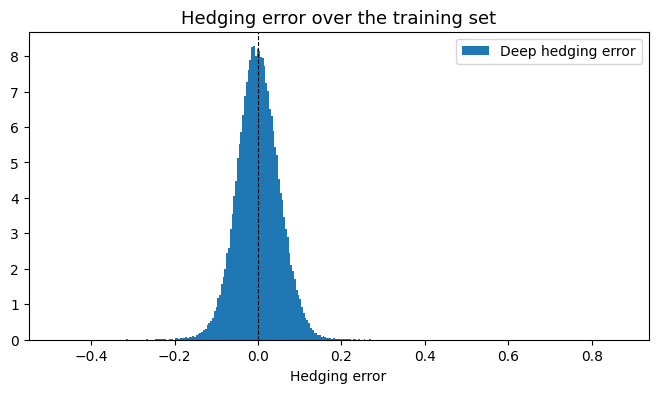

Learned option premium π_0            : 0.2446
Monte Carlo reference price            : 0.3001  (±0.00046)

Deep hedging error — train set
  Mean  : 3.0851e-04
  Std   : 5.0995e-02


In [11]:
hedging_error_train = model_output[:, 0]  # type: ignore
learned_premium     = float(model_output[0, -1])  # type: ignore  # same for all rows

plt.figure(figsize=(8, 4))
plt.hist(hedging_error_train, bins=int(np.sqrt(N_train)), density=True, label="Deep hedging error")
plt.axvline(0, linestyle='--', linewidth=0.8, color='k')
plt.title("Hedging error over the training set", fontsize=13)
plt.xlabel("Hedging error")
plt.legend(loc="best")
plt.show()

print("Learned option premium π_0            : %1.4f" % learned_premium)
print("Monte Carlo reference price            : %1.4f  (±%1.5f)" % (price_MC, price_MC_std))
print("")
print("Deep hedging error — train set")
print("  Mean  : %1.4e" % np.mean(hedging_error_train))
print("  Std   : %1.4e" % np.std(hedging_error_train))

**Commentary on the training results.**

The learned option premium $\pi_\theta(S^1_0, S^2_0)$ should be close to the Monte Carlo reference price. A small mean hedging error (close to zero) indicates that the network has correctly learned to price the option. The standard deviation of the hedging error measures the residual hedging risk that cannot be eliminated by any static or dynamic strategy with two assets.

Compared to the 1D case, a higher hedging error variance is expected because:
- The product payoff $S^1_T S^2_T$ is non-linear and harder to hedge than a simple call.
- The interaction between the two correlated assets introduces additional unhedgeable risk (especially when $\rho$ is not $\pm 1$).

## Out-of-sample test set

$\blacktriangleright$ We evaluate the deep hedging model on a **fresh test set** of $N_{test} = 10^4$ trajectories.

  1/313 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step

  7/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step 

 13/313 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

 19/313 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step 

 24/313 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

...

300/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


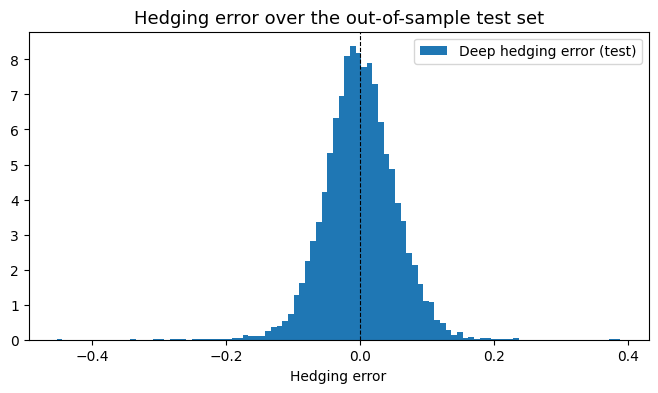

Deep hedging error — test set
  Mean  : 1.6201e-04
  Std   : 5.2552e-02


In [12]:
N_test_paths = 10**4

# Fresh correlated log-increments for the test set
log_increments_test = [
    mu_vec * Delta_T + sigma_vec * np.sqrt(Delta_T) * (np.random.normal(0, 1, (N_test_paths, 2)) @ L.T)
    for _ in range(N)
]

S1_eval_test = S1_0 * np.linspace(0.5, 1.5, N_test_paths)
hedge_eval_test = np.column_stack([S1_eval_test, S2_0 * np.ones(N_test_paths)])

xtest_paths = (
    [np.column_stack([S1_0 * np.ones(N_test_paths), S2_0 * np.ones(N_test_paths)])]
    + [np.zeros((N_test_paths, 1))]
    + [hedge_eval_test]
    + [np.zeros((N_test_paths, m))]
    + log_increments_test
)

model_output_test = model_hedge_strat.predict(xtest_paths)  # type: ignore
hedging_error_test = model_output_test[:, 0]  # type: ignore

plt.figure(figsize=(8, 4))
plt.hist(hedging_error_test, bins=int(np.sqrt(N_test_paths)), density=True, label="Deep hedging error (test)")
plt.axvline(0, linestyle='--', linewidth=0.8, color='k')
plt.title("Hedging error over the out-of-sample test set", fontsize=13)
plt.xlabel("Hedging error")
plt.legend(loc="best")
plt.show()

print("Deep hedging error — test set")
print("  Mean  : %1.4e" % np.mean(hedging_error_test))
print("  Std   : %1.4e" % np.std(hedging_error_test))

## Delta profiles

$\blacktriangleright$ We visualise the learned hedging strategies $\delta^1_{t_l}(S^1, S^2_0)$ and $\delta^2_{t_l}(S^1, S^2_0)$ as functions of $S^1$ (with $S^2$ fixed at its initial value $S^2_0 = 1$), for a chosen time $t_l$.

In [13]:
# Build a dedicated delta-visualisation test set
N_delta = 200  # number of points on the S1 grid

S1_eval = S1_0 * np.linspace(0.3, 2.0, N_delta).reshape(N_delta, 1)
S2_fixed = S2_0 * np.ones((N_delta, 1))
hedge_eval_delta = np.hstack([S1_eval, S2_fixed])  # shape (N_delta, 2)

log_incr_zeros = [np.zeros((N_delta, m)) for _ in range(N)]

xtest_delta = (
    [np.hstack([S1_0 * np.ones((N_delta, 1)), S2_0 * np.ones((N_delta, 1))])]
    + [np.zeros((N_delta, 1))]
    + [hedge_eval_delta]
    + [np.zeros((N_delta, m))]
    + log_incr_zeros
)

output_delta = model_hedge_strat.predict(xtest_delta)  # type: ignore

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


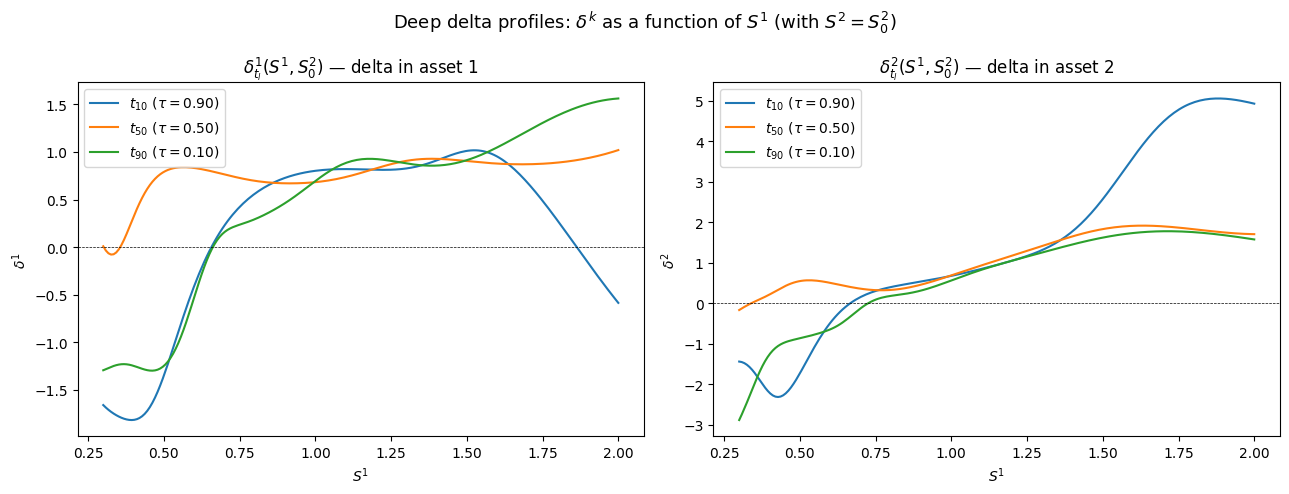

In [14]:
# Plot delta profiles for three time steps: early, mid, late maturity
time_steps = [10, 50, 90]
S1_grid_plot = S1_eval[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for l in time_steps:
    # Column indices: 1 + l*m  = δ1 at step l,  1 + l*m + 1 = δ2 at step l
    delta1_l = output_delta[:, 1 + l * m]       # type: ignore
    delta2_l = output_delta[:, 1 + l * m + 1]   # type: ignore
    tau = T - grid[l]
    axes[0].plot(S1_grid_plot, delta1_l, label=r"$t_{%d}$ ($\tau=%.2f$)" % (l, tau))
    axes[1].plot(S1_grid_plot, delta2_l, label=r"$t_{%d}$ ($\tau=%.2f$)" % (l, tau))

axes[0].set_title(r"$\delta^1_{t_l}(S^1, S^2_0)$ — delta in asset 1", fontsize=12)
axes[0].set_xlabel(r"$S^1$")
axes[0].set_ylabel(r"$\delta^1$")
axes[0].axhline(0, linestyle='--', linewidth=0.5, color='k')
axes[0].legend(loc="best")

axes[1].set_title(r"$\delta^2_{t_l}(S^1, S^2_0)$ — delta in asset 2", fontsize=12)
axes[1].set_xlabel(r"$S^1$")
axes[1].set_ylabel(r"$\delta^2$")
axes[1].axhline(0, linestyle='--', linewidth=0.5, color='k')
axes[1].legend(loc="best")

plt.suptitle(r"Deep delta profiles: $\delta^k$ as a function of $S^1$ (with $S^2 = S^2_0$)", fontsize=13)
plt.tight_layout()
plt.show()

**Commentary on the delta profiles.**

The shape of the learned delta functions is qualitatively sensible:

- **$\delta^1$** is increasing in $S^1$: when $S^1$ is high, the product $S^1_T S^2_T$ is more likely to exceed the strike, so a larger hedge in asset 1 is needed. This is analogous to the $N(d_1)$ profile of the Black-Scholes delta for a call.
- **$\delta^2$** exhibits a similar pattern as a function of $S^1$ (through the correlation $\rho = 0.5$): a higher $S^1$ is correlated with a higher $S^2$, making the option more in-the-money.
- As maturity approaches ($\tau \to 0$), the delta profiles sharpen around the at-the-money level, as expected for digital-like behaviour near expiry.

## Summary and criticism

**Summary:**
- The deep model learns a premium close to the Monte Carlo estimate, confirming convergence.
- The hedging error distribution is approximately centred at zero with a spread that reflects the irreducible hedging risk of the product payoff.
- The delta profiles have qualitatively correct shapes.

**Critical assessment:**
- Since there is no closed-form benchmark for this payoff, we cannot directly compare the deep hedge with the theoretically optimal strategy. A Monte Carlo estimation of the minimal hedging variance (via regression-based methods such as Longstaff-Schwartz) would provide a stronger reference.
- The model uses separate networks for each of the $N=100$ time steps, which leads to a large number of parameters ($100 \times 2$ networks). A single network with time as an additional input (as explored in the $n$-dimensional notebook) is more parameter-efficient.
- With $N_{train} = 10^5$, training is already quite slow. In practice, larger batch sizes and/or a reduced number of time steps (e.g. $N=20$) could be used to speed up convergence without significantly affecting the quality of the hedge.

---

**To go further.** The deep hedging framework extends naturally to:
- more complex dynamics (stochastic volatility, jumps),
- non-standard option payoffs,
- transaction costs and market friction (the original motivation of Bühler et al., 2018).

See the $n$-dimensional notebook (`Deep_hedging_nD.ipynb`) for a generalisation to an arbitrary number of assets.